### import the required libraries


In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from fontTools.t1Lib import assertType1
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier

In [40]:
# load the data into dataframe

df = pd.read_csv('../data/heart.csv')


In [63]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [43]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Handling Missing Values

In [44]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [45]:
# duplicate copy before doing features enginering
df_copy = df.copy()

### Features Engineering

In [46]:
# Binning the age into the age groups likes '30s, 40s, ....70s
bins = [30,40,50,60,70,80]
labels = ['30s','40s','50s','60s','70s']
#create new columns
df_copy['age_bin'] = pd.cut(df_copy['age'], bins = bins, labels = labels)


In [47]:
df_copy['age_bin'].value_counts()

age_bin
50s    438
60s    252
40s    247
30s     64
70s     20
Name: count, dtype: int64

In [48]:
# covnert chol into levels :'Normal, borderline, high
bins = [0,200,239,np.inf]
labels =['Normal','Borderline','High']

#create new column
df_copy['chol_level'] = pd.cut(df_copy['chol'], bins= bins, labels = labels)

In [49]:
df_copy['chol_level'].value_counts()

chol_level
High          517
Borderline    336
Normal        172
Name: count, dtype: int64

### Features Creation

In [50]:
# create new features pluseto age ratio

df_copy['pulse_age_ratio'] = round(df_copy['thalach'] / (df_copy['age'] + 1),2)

In [51]:
df_copy.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_bin,chol_level,pulse_age_ratio
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,50s,Borderline,3.17
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,50s,Borderline,2.87
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,60s,Normal,1.76
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,60s,Borderline,2.60
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,60s,High,1.68
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1,50s,High,2.07
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0,50s,High,2.37
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0,50s,High,2.59
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0,40s,High,3.06
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0,50s,High,2.11


### Encode categorical varibles using one-hot encoding.


In [52]:
# include : sex,cp, fbs, restecg, exang, slope, thal, and the two new binned fearues
# drop the first category in each to avoid multicollinearity
df_copy.dtypes

age                   int64
sex                   int64
cp                    int64
trestbps              int64
chol                  int64
fbs                   int64
restecg               int64
thalach               int64
exang                 int64
oldpeak             float64
slope                 int64
ca                    int64
thal                  int64
target                int64
age_bin            category
chol_level         category
pulse_age_ratio     float64
dtype: object

In [53]:

# Identify categorical columns
categorical_cols = df_copy.select_dtypes(include='category').columns.tolist()

# Add extra known categorical columns
categorical_cols += ['sex','cp','fbs','restecg','exang','slope','thal']
#muticollinearity
df_copy = pd.get_dummies(df_copy, columns=[col for col in  categorical_cols if col != 'target'], drop_first= True)
df_copy.head()

,age,trestbps,chol,thalach,oldpeak,ca,target,pulse_age_ratio,age_bin_40s,age_bin_50s,...,cp_3,fbs_1,restecg_1,restecg_2,exang_1,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,2,0,3.17,False,True,...,False,False,True,False,False,False,True,False,False,True
1,53,140,203,155,3.1,0,0,2.87,False,True,...,False,True,False,False,True,False,False,False,False,True
2,70,145,174,125,2.6,0,0,1.76,False,False,...,False,False,True,False,True,False,False,False,False,True
3,61,148,203,161,0.0,1,0,2.60,False,False,...,False,False,True,False,False,False,True,False,False,True
4,62,138,294,106,1.9,3,0,1.68,False,False,...,False,True,True,False,False,True,False,False,True,False


In [54]:
df_copy.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'target',
       'pulse_age_ratio', 'age_bin_40s', 'age_bin_50s', 'age_bin_60s',
       'age_bin_70s', 'chol_level_Borderline', 'chol_level_High', 'sex_1',
       'cp_1', 'cp_2', 'cp_3', 'fbs_1', 'restecg_1', 'restecg_2', 'exang_1',
       'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3'],
      dtype='str')

In [55]:
# Only convert boolean columns to int
bool_cols = df_copy.select_dtypes(include='bool').columns
df_copy[bool_cols] = df_copy[bool_cols].astype(int)

In [56]:
df_copy.head()

,age,trestbps,chol,thalach,oldpeak,ca,target,pulse_age_ratio,age_bin_40s,age_bin_50s,...,cp_3,fbs_1,restecg_1,restecg_2,exang_1,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,2,0,3.17,0,1,...,0,0,1,0,0,0,1,0,0,1
1,53,140,203,155,3.1,0,0,2.87,0,1,...,0,1,0,0,1,0,0,0,0,1
2,70,145,174,125,2.6,0,0,1.76,0,0,...,0,0,1,0,1,0,0,0,0,1
3,61,148,203,161,0.0,1,0,2.60,0,0,...,0,0,1,0,0,0,1,0,0,1
4,62,138,294,106,1.9,3,0,1.68,0,0,...,0,1,1,0,0,1,0,0,1,0


### Standardize the numeric features

In [57]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'pulse_age_ratio']

scaler = StandardScaler()
df_scaled = df_copy.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])


In [58]:
df_scaled

,age,trestbps,chol,thalach,oldpeak,ca,target,pulse_age_ratio,age_bin_40s,age_bin_50s,...,cp_3,fbs_1,restecg_1,restecg_2,exang_1,slope_1,slope_2,thal_1,thal_2,thal_3
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,2,0,0.456404,0,1,...,0,0,1,0,0,0,1,0,0,1
1,-0.158157,0.479107,-0.833861,0.255968,1.727137,0,0,0.084985,0,1,...,0,1,0,0,1,0,0,0,0,1
2,1.716595,0.764688,-1.396233,-1.048692,1.301417,0,0,-1.289262,0,0,...,0,0,1,0,1,0,0,0,0,1
3,0.724079,0.936037,-0.833861,0.516900,-0.912329,1,0,-0.249291,0,0,...,0,0,1,0,0,0,1,0,0,1
4,0.834359,0.364875,0.930822,-1.874977,0.705408,3,0,-1.388307,0,0,...,0,1,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,0.503520,0.479107,-0.484803,0.647366,-0.912329,0,1,-0.088343,0,1,...,0,0,1,0,1,0,1,0,1,0
1021,0.613800,-0.377636,0.232705,-0.352873,1.471705,1,0,-0.608329,0,1,...,0,0,0,0,1,1,0,0,0,1
1022,-0.819834,-1.234378,0.562371,-1.353113,-0.060888,1,0,-0.422620,1,0,...,0,0,0,0,1,1,0,0,1,0
1023,-0.488996,-1.234378,0.155137,0.429923,-0.912329,0,1,0.394500,1,0,...,0,0,0,0,0,0,1,0,1,0


In [59]:
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1025 non-null   float64
 1   trestbps               1025 non-null   float64
 2   chol                   1025 non-null   float64
 3   thalach                1025 non-null   float64
 4   oldpeak                1025 non-null   float64
 5   ca                     1025 non-null   int64  
 6   target                 1025 non-null   int64  
 7   pulse_age_ratio        1025 non-null   float64
 8   age_bin_40s            1025 non-null   int64  
 9   age_bin_50s            1025 non-null   int64  
 10  age_bin_60s            1025 non-null   int64  
 11  age_bin_70s            1025 non-null   int64  
 12  chol_level_Borderline  1025 non-null   int64  
 13  chol_level_High        1025 non-null   int64  
 14  sex_1                  1025 non-null   int64  
 15  cp_1           

### Data Exploraton and Visualisation

<Figure size 1500x1200 with 0 Axes>

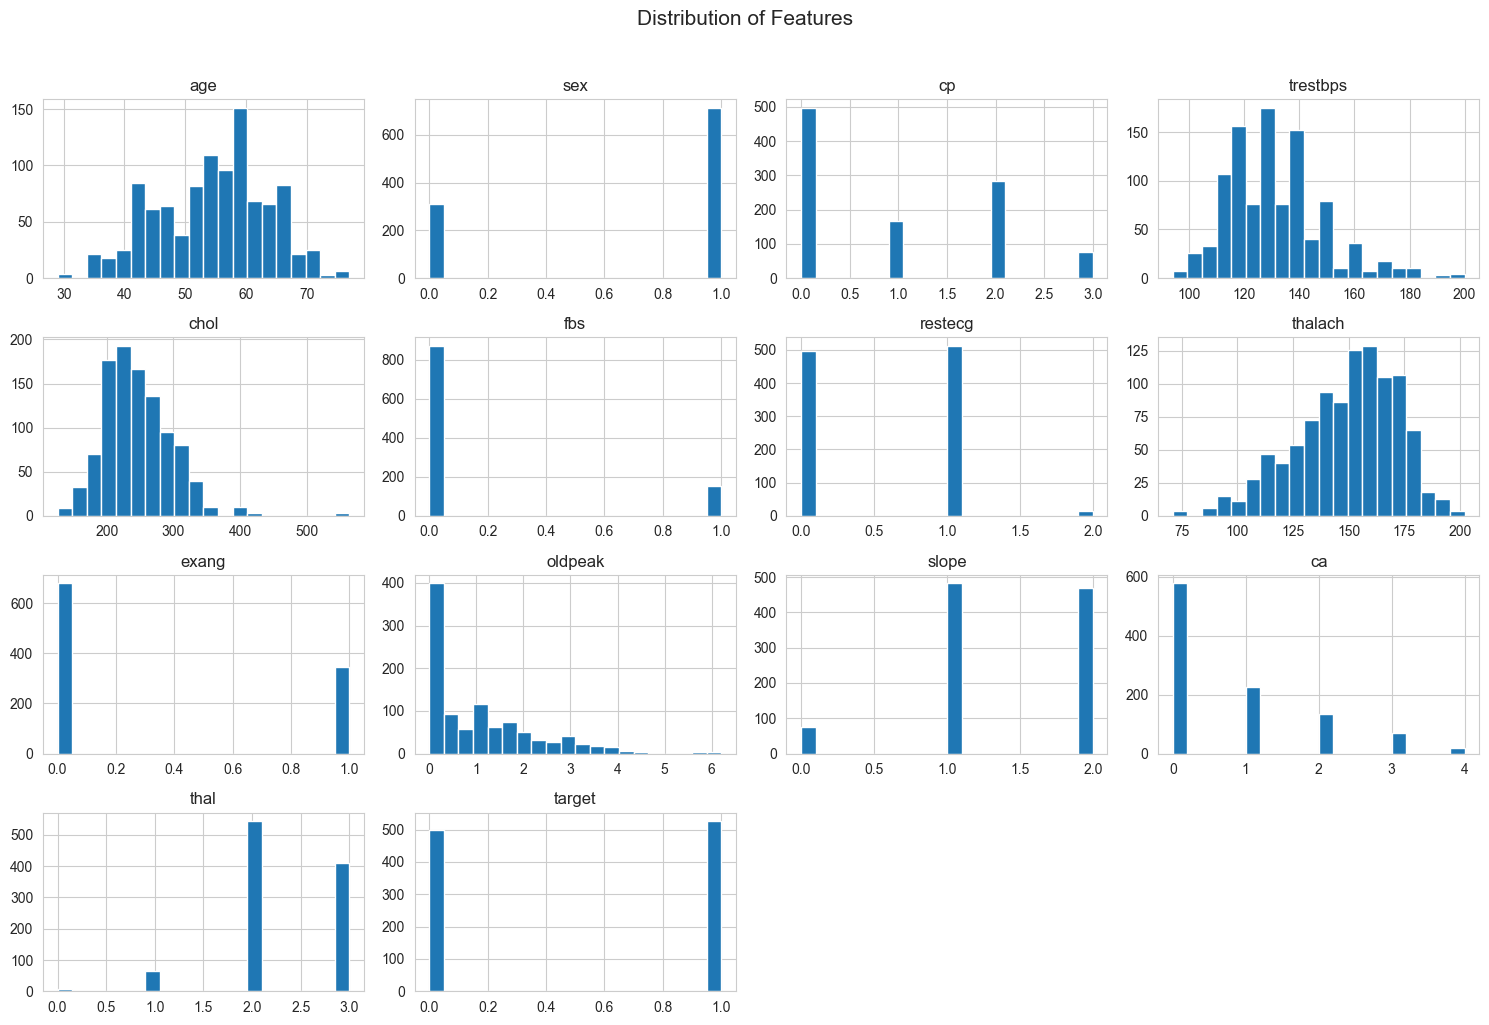

In [60]:
# set up the plotting environment
plt.figure(figsize=(15,12))

#1. distribution of each featuers

df.hist(bins = 20, figsize=(15,10))
plt.suptitle("Distribution of Features", fontsize = 15, y = 1.02)
plt.tight_layout()
plt.show()

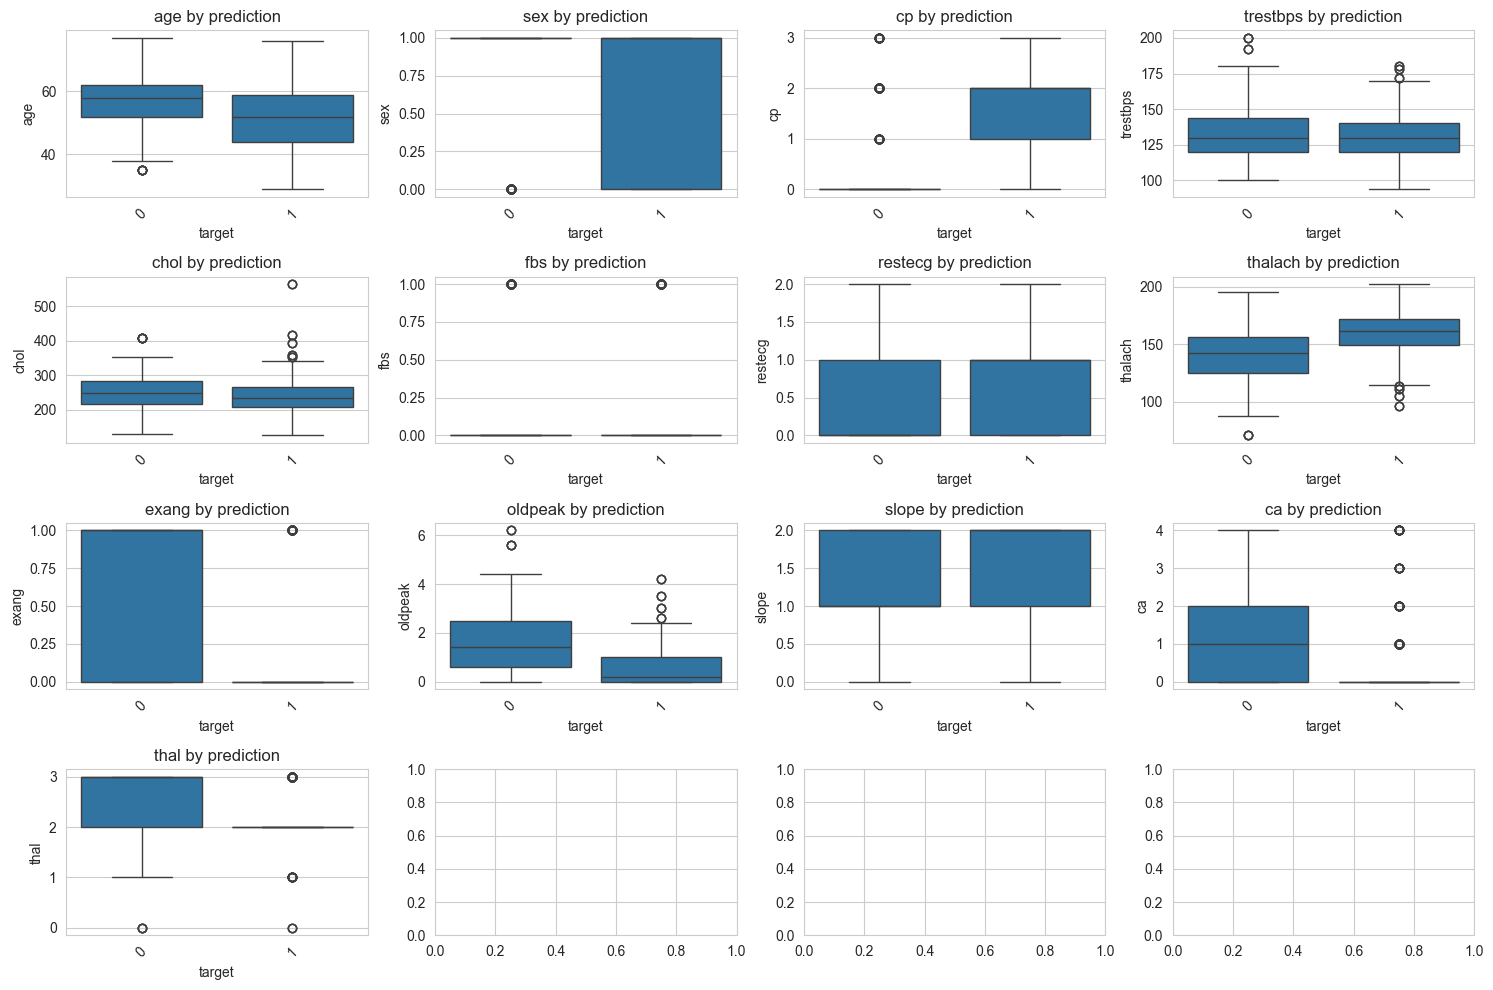

In [61]:
# box plots for each feautures by  target

fig, axes = plt.subplots(4,4, figsize = (15,10))
features = [col for col in df.columns if col != 'target']

for i, feature in enumerate(features):
    row = i // 4
    col = i % 4
    sns.boxplot(data = df, x = 'target', y = feature, ax = axes[row, col])
    axes[row,col].set_title(f'{feature} by prediction')
    axes[row,col].tick_params(axis ='x', rotation = 45)

plt.tight_layout()
plt.show()

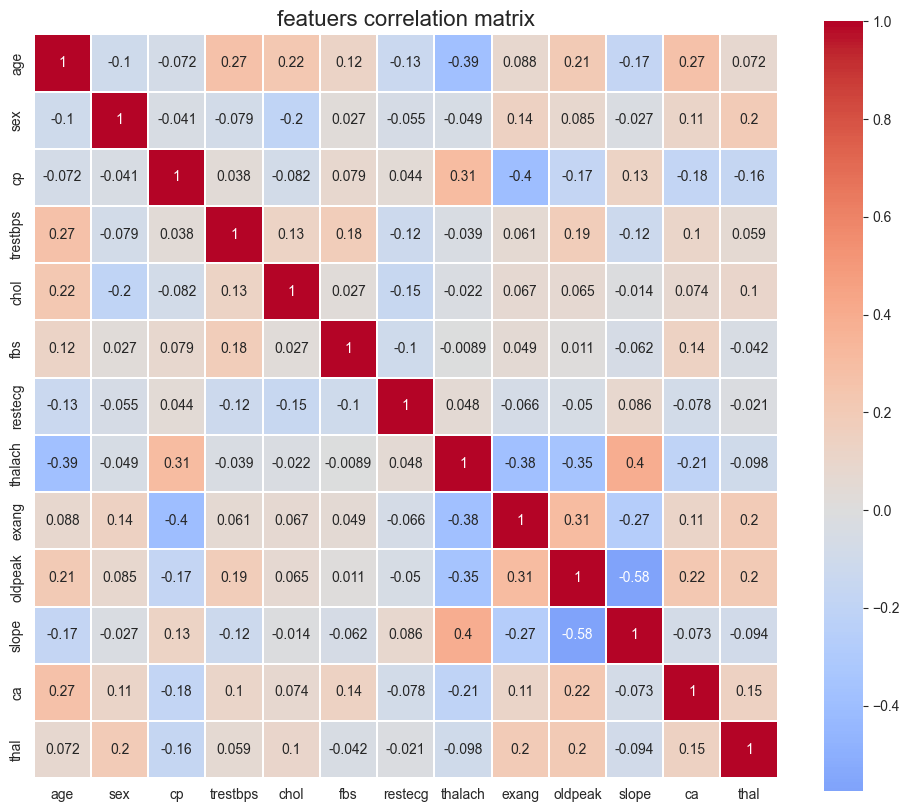

In [62]:
# correlation matrix
df_features = df[features].select_dtypes(include='number')
plt.figure(figsize=(12,10))
corr_matrix = df_features.corr()
sns.heatmap(corr_matrix, annot= True, cmap ='coolwarm', center = 0, square = True, linewidths= 0.2)
plt.title('featuers correlation matrix', fontsize = 16)
plt.show()

### Export the final cleaned and processed dataset**

In [65]:
df_scaled.to_csv('../data/heart_disease_cleaned.csv', index = False)